Utilizando los hiperparametros definidos en el siguiente paper:
[1]
W. Cambronero, “Poker Hand Dataset: A Machine Learning Analysis and a Practical Linear Transformation.” Accessed: Apr. 22, 2026. [Online]. Available: https://walintonc.github.io/papers/ml_pokerhand.pdf

‌

In [9]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.optimizers import Adam as adam
from tensorflow.keras.callbacks import EarlyStopping

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 100)            │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,810 (93.01 KB)

 Trainable params: 23,810 (93.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2631 - loss: 1.6474 - val_accuracy: 0.3207 - val_loss: 1.4213
Epoch 2/200
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3145 - loss: 1.5454 - val_accuracy: 0.3268 - val_loss: 1.4570
Epoch 3/200
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3354 - loss: 1.4889 - val_accuracy: 0.3829 - val_loss: 1.4148
Epoch 4/200
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3562 - loss: 1.4397 - val_accuracy: 0.3477 - val_loss: 1.4188
Epoch 5/200
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3649 - loss: 1.4129 - val_accuracy: 0.4324 - val_loss: 1.3151
Epoch 6/200
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3784 - loss: 1.3935 - val_accuracy: 0.4015 - val_loss: 1.3382
Epoch 7/200
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3865 - loss: 1.3752 - val_accuracy: 0.4240 - val_loss: 1.3239
Epoch 8/200
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3959 - loss: 1.3610 - val_accu

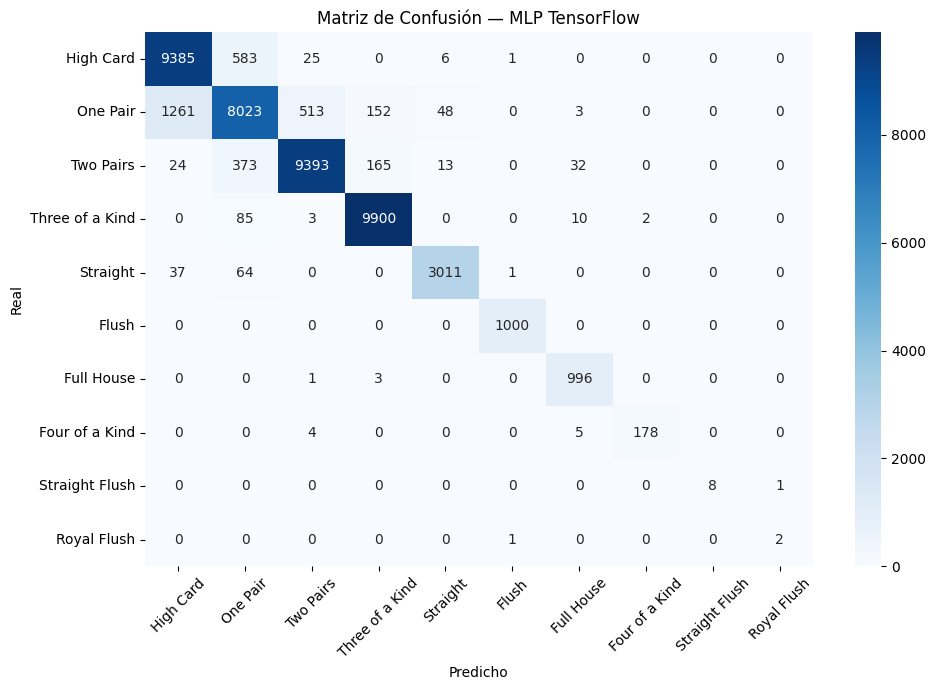

In [10]:
# Se lee el dataset preprocesado
df = pd.read_csv('../../preprocesamiento/preprocesamiento_trainning.data', header=None)
df_val = pd.read_csv('../../preprocesamiento/preprocesamiento_validation.data', header=None)


x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
x_val = df_val.iloc[:, :-1].values
y_val = df_val.iloc[:, -1].values

clases = sorted(np.unique(y).astype(int).tolist())
clase_nombres = {
    0: "High Card", 1: "One Pair", 2: "Two Pairs", 3: "Three of a Kind",
    4: "Straight",  5: "Flush",   6: "Full House", 7: "Four of a Kind",
    8: "Straight Flush", 9: "Royal Flush"
}
nombres_ordenados = [clase_nombres[c] for c in clases]

# Número de clases distintas
# Número de características (features) por muestra
n_clases = len(np.unique(y))
n_features = x.shape[1]


modelo_tf = keras.Sequential([    
    # Capa de entrada: recibe vectores de tamaño n_features
    keras.layers.Input(shape=(n_features,)),
    # Primera capa oculta con 100 neuronas y activación ReLU
    keras.layers.Dense(100, activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001)),
    # Segunda capa oculta con 10 neuronas y activación ReLU
    keras.layers.Dense(100, activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001)),
    # Tercera capa oculta con 100 neuronas y activación ReLU
    keras.layers.Dense(100, activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001)),
    # Capa de salida:
    # n_clases neuronas (una por clase)
    # softmax convierte las salidas en probabilidades
    keras.layers.Dense(n_clases, activation='softmax')
])


# Compilación del modelo:
modelo_tf.compile(
    optimizer=adam(learning_rate=0.01),  
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Muestra un resumen del modelo (capas, parámetros, etc.)
modelo_tf.summary()

history = modelo_tf.fit(
    x, y,
    epochs=200,
    batch_size=200,
    validation_data=(x_val, y_val), 
    verbose=1
)

EarlyStopping(patience=10, restore_best_weights=True)

# Predicciones del modelo (probabilidades por clase)
y_pred_tf = np.argmax(modelo_tf.predict(x), axis=1)

# Se usa argmax para convertir probabilidades en la clase con mayor valor

# Accuracy: proporción de aciertosprint(f"Accuracy : {accuracy_score(y, y_pred_tf):.4f}")# Recall macro: promedio del recall por clase (útil en datasets desbalanceados)print(f"Recall   : {recall_score(y, y_pred_tf, average='macro', zero_division=0):.4f}")# F1-score macro: balance entre precisión y recall por clase
print(f"Accuracy : {accuracy_score(y, y_pred_tf):.4f}")
print(f"Recall   : {recall_score(y, y_pred_tf, average='macro'):.4f}")
print(f"F1       : {f1_score(y, y_pred_tf, average='macro', zero_division=0):.4f}")

y_pred_val = np.argmax(modelo_tf.predict(x_val), axis=1)

print(f"Accuracy (val): {accuracy_score(y_val, y_pred_val):.4f}")
print(f"Recall   (val): {recall_score(y_val, y_pred_val, average='macro'):.4f}")
print(f"F1       (val): {f1_score(y_val, y_pred_val, average='macro'):.4f}")

# Calcula la matriz de confusión
cm_tf = confusion_matrix(y, y_pred_tf)
modelo_tf.evaluate(x_val, y_val)

# Se grafica con seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_tf, 
    annot=True,        # muestra números dentro de cada celda
    fmt='d',           # formato entero
    cmap='Blues',      # esquema de colores
    xticklabels=nombres_ordenados,
    yticklabels=nombres_ordenados,
)

# Etiquetas del gráfico
plt.title("Matriz de Confusión — MLP TensorFlow")
plt.xlabel("Predicho")
plt.ylabel("Real")

# Ajustes visuales
plt.tick_params(axis='x', rotation=45)
plt.tick_params(axis='y', rotation=0)
plt.tight_layout()

# Mostrar gráfico
plt.show()

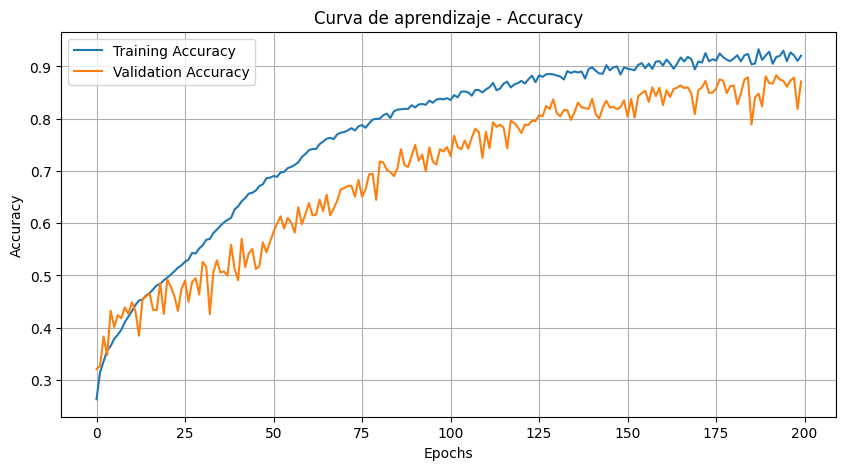

In [11]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Curva de aprendizaje - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

In [12]:
modelo_tf.save("modelo_poker_optimizado.keras")